# Classifying Fast-Spiking and Regular-Spiking Neurons

In this notebook, we will classify **fast-spiking (FS)** neurons from **regular-spiking (RS)** neurons in visual cortical areas of the mouse brain. We will also visualize the differences between these two types of cells by comparing their peak waveforms and optotagged unit responses. This notebook utilizes open source data from the Allen Institute, but is designed to be customizable with alternative datasets.

## Environment Setup
⚠️**Note: If running on a new environment, run this cell once and then restart the kernel**⚠️

In [ ]:
try:
    from databook_utils.dandi_utils import dandi_download_open
except:
    !git clone --depth 1 https://github.com/AllenInstitute/openscope_databook.git
    %cd openscope_databook
    %pip install -e .

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from databook_utils.dandi_utils import dandi_stream_open
from hdmf.common import DynamicTable
from pynwb import NWBHDF5IO
from pynwb.misc import Units

%matplotlib inline

## Streaming Ecephys Files

In [3]:
dandiset_id = "000021"
dandi_filepath = "sub-707296975/sub-707296975_ses-721123822.nwb"
dandi_api_key = None

In [4]:
# This can sometimes take a while depending on the size of the file
io = dandi_download_open(dandiset_id, dandi_filepath, dandi_api_key=dandi_api_key)
nwb = io.read()

File already exists
Opening file


## Accessing Data Tables
Here, we want to access data from the `Units` table of the NWB file. This table contains information about each unit from a given experiment. A unit typically refers to an individual neuron that is recorded during an extracellular electrophysiology experiment. We will also be accessing data from the `Electrodes` table of the NWB file. This table contains information about each electrode (neuropixel probe) that was used during this experiment. This is a useful place to get information about specific channels, or recording sites, that are positioned along the probe. While we will not use every column of data from both of these tables, the relevant data we extract will be explained below. 

In [5]:
# take long time up front, but makes analysis much faster
units = nwb.units.to_dataframe()
units[:10]

,amplitude_cutoff,firing_rate,presence_ratio,snr,velocity_below,isolation_distance,silhouette_score,velocity_above,nn_miss_rate,PT_ratio,...,cluster_id,waveform_halfwidth,waveform_duration,recovery_slope,amplitude,spread,isi_violations,spike_times,spike_amplitudes,waveform_mean
id,,,,,,,,,,,,,,,,,,,,,
950907203,0.376577,2.533384,0.99,2.830406,NaN,6.340840e+01,NaN,0.073582,0.000781,0.545221,...,0,0.151089,0.274707,-0.044249,45.540300,70.0,0.06548,"[1.8463237565528026, 1.9619905358580827, 2.311...","[8.327628219252525e-05, 8.367903428567035e-05,...","[[0.0, 1.4724449999999971, -0.393510000000004,..."
950907522,0.022585,0.055246,0.65,0.622514,NaN,1.211930e+01,NaN,-0.171692,0.001937,0.354055,...,153,0.219765,0.480737,-0.007213,49.501937,70.0,0.00000,"[75.19259518261279, 186.3849701306289, 191.589...","[7.996977585316541e-05, 6.97690878117426e-05, ...","[[0.0, -1.6420295202952053, 2.3475553505535047..."
950907205,0.012123,14.739577,0.99,2.838052,NaN,1.291725e+02,0.193312,-0.892797,0.004831,1.054721,...,1,0.109883,0.151089,-0.244173,101.262915,40.0,0.00510,"[0.6211892301590656, 0.9079561760850958, 1.081...","[5.270051606545425e-05, 5.0142859160195626e-05...","[[0.0, -0.9787049999999999, -4.640805000000003..."
950907520,0.007576,1.098404,0.99,2.423808,NaN,6.282138e+01,0.137635,0.824121,0.001901,0.456900,...,152,0.206030,0.329648,-0.053915,85.989735,50.0,0.00000,"[2.1005573374638606, 3.85505904603257, 4.01682...","[7.694648306411865e-05, 7.492886255594172e-05,...","[[0.0, -1.4923350000000075, -1.402439999999998..."
950907518,0.075400,0.062280,0.87,2.263385,NaN,3.500339e+01,0.173800,0.206030,0.000000,0.434353,...,151,0.178559,0.343384,-0.053040,84.470426,50.0,0.00000,"[1.9085904838560483, 5.879527684167119, 31.678...","[7.178091557968419e-05, 6.456652055153236e-05,...","[[0.0, -3.4937234042553165, 3.7997872340425505..."
950907524,0.002313,1.448536,0.99,4.285082,0.686767,5.045019e+01,0.143138,0.068677,0.001834,0.558508,...,154,0.164824,0.357119,-0.123923,136.843200,60.0,0.00000,"[2.348824245897788, 2.5458577711062924, 2.6720...","[0.00011948493821011336, 0.0001511098249575643...","[[0.0, 2.527005000000001, 1.158495000000003, 0..."
950907209,0.084063,0.040263,0.96,3.343694,0.000000,1.992695e+01,NaN,0.156975,0.000467,0.637890,...,3,0.178559,0.343384,-0.115789,114.131278,70.0,0.00000,"[10.606598954149941, 21.535109596551273, 52.97...","[9.775257470604628e-05, 9.453428297313494e-05,...","[[0.0, 3.588493670886069, 2.7976329113924, 1.2..."
950907207,0.500000,0.007849,0.04,1.429174,-1.373534,1.143549e+02,NaN,1.178950,0.000067,1.086981,...,2,0.137353,0.467002,-0.087455,58.044156,100.0,0.00000,"[9220.822768046102, 9221.122635004784, 9221.42...","[6.54109900575074e-05, 7.75283889854388e-05, 6...","[[0.0, 0.48370129870129897, 2.144999999999998,..."
950907528,0.500000,0.003160,0.29,2.618464,0.343384,1.376060e+13,NaN,0.629537,0.000000,0.551650,...,156,0.164824,0.315913,-0.106002,82.516452,110.0,0.00000,"[380.3052589740686, 1307.7695954906458, 1546.2...","[7.262832980570496e-05, 8.690587004932377e-05,...","[[0.0, -13.234838709677422, -15.53080645161290..."


In [6]:
# convert the electrodes table into a pandas df for easier analysis
electrodes = nwb.electrodes
electrodes_df = electrodes.to_dataframe()

# Reset the index to include it as a regular column
electrodes_df.reset_index(inplace=True)

electrodes_df[:10]

,id,x,y,z,imp,location,filtering,group,group_name,probe_vertical_position,probe_horizontal_position,probe_id,local_index,valid_data
0,850243981,8470.0,3169.0,3169.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,20,43,760213137,0,True
1,850243983,8466.0,3160.0,3160.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,20,11,760213137,1,True
2,850243985,8461.0,3152.0,3152.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,40,59,760213137,2,True
3,850243987,8456.0,3144.0,3144.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,40,27,760213137,3,True
4,850243989,8452.0,3135.0,3135.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,60,43,760213137,4,True
5,850243991,8447.0,3127.0,3127.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,60,11,760213137,5,True
6,850243993,8442.0,3119.0,3119.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,80,59,760213137,6,True
7,850243995,8438.0,3110.0,3110.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,80,27,760213137,7,True
8,850243997,8433.0,3102.0,3102.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,100,43,760213137,8,True
9,850243999,8429.0,3093.0,3093.0,NaN,MB,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,probeA abc.EcephysElectrodeGroup at 0x21189799...,probeA,100,11,760213137,9,True


## Selecting and Aligning Particular Data From the Tables
Now we want to extract and align particular data from the `Units` and `Electrodes` tables from above. There are several criteria that need to be met in order for us to select only specific neurons that will be valuable to our analysis: 
1) **Location**: The tables above contain information from every area of the brain that the probes were inserted into. However, we only want to analyze data that was collected from areas on the probe that were inserted into the visual cortical areas of the mouse brain. For this reason, we create a dictionary called `channel_to_probes_dict` to map each channel of each probe to its position within the brain so we can exclude units that are not from these desired areas. Since the channel location information is stored in the `Electrodes` table, we wrote a function called `get_unit_location` where we can input a `peak_channel_id` from the stimulus table and receive the location of the channel. This function allows us to align data from the `Electrodes` table with data from the `Units` table. We use the `cortex` list to identify which units we want to select for particular coritcal locations in the example below, and exclude any units that are not from these particular locations in the list.
2) **Electrode Validity**: The last column of the `Electrodes` table is labeled `valid_data` and tells us if data from a specific channel was valid or not. We only want to include data from channels that are 'True' (valid) for this column. We write a function called `is_electrode_valid` that will create a list of the `id` of each channel that provides valid data, so we can exclude any channel from our analysis that does not meet this criteria.
3) **Unit Quality**: One of the columns in the `Units` table called `quality` contains information about the quality of the data of each unit. We only want to include units in our analysis that have 'good' quality and are not 'noise'. To exclude the noisy units, we create a function that will return 'True' only when the unit's quality is 'good'. 

In [7]:
# In older Allen NWBs the information must be manually cross-referenced between the units table and electrodes table

# create a dictionary that maps the id of a channel to its location 
channel_to_probes_dict = {}

for i in range(len(electrodes_df)):
    channel_id = electrodes_df['id'][i]
    location = electrodes_df['location'][i]
    channel_to_probes_dict[channel_id] = location

def get_peak_channel_idx(unit_row):
    return unit_row['peak_channel_id']

# function aligns location information from electrodes table with channel id from the units table
def get_unit_location(peak_id):
    return channel_to_probes_dict[peak_id]



# In newer Allen NWBs, the units table includes direct references to each unit's electrodes, so we can access them directly
# def get_peak_channel_idx(unit_row):
#     mean_waveforms = unit_row['waveform_mean']
#     waveform_mins = np.min(mean_waveforms, axis=0)
#     peak_channel_idx = np.argmin(waveform_mins)
#     return peak_channel_idx

# def get_unit_location(unit_row):
#     peak_channel_idx = get_peak_channel_idx(unit_row)
#     detected_electrodes = unit_row['electrodes']
#     return detected_electrodes.iloc[peak_channel_idx].location

In [8]:
# returns a set of channel ids that are valid within electrodes table

# older Allen NWBs used the valid_data column
if 'valid_data' in electrodes_df.columns:
    valid_electrode_ids = electrodes_df.loc[electrodes_df['valid_data'] == True, 'id'].tolist()
# newer Allen NWBs only include valid channels in the electrodes table, so we can just take all of the ids
else:
    valid_electrode_ids = electrodes_df['id'].tolist()

valid_electrode_id = set(valid_electrode_ids)

Now that we have defined some of the criteria for selecting data, we can combine what we have with some additional filtering criteria into one unified function called `select_unit` that will be used in a for loop below. When data from a specific unit is passed into this function, the function will return 'True' if that unit meets all the defined criteria. This will help us exclude units that do not meet the criteria in the loop below. You can modify this function to fit whatever criteria is most reasonable for your dataset. 

In [9]:
cortex = ['VISrl', 'VISal', 'VISam', 'VISpm', 'VISp', 'VISI']

# this will work for older Allen NWBs
def select_unit(unit_row):
    if (unit_row['quality'] == 'good' and
    get_unit_location(unit_row['peak_channel_id']) in cortex and
    unit_row['peak_channel_id'] in valid_electrode_ids and
    unit_row['isi_violations'] < 0.5 and
    unit_row['amplitude_cutoff'] < 0.1 and
    unit_row['presence_ratio'] > 0.95):
        return True

# this will work for newer Allen NWBs
# def select_unit(unit_row):
# 	if unit_row['decoder_label'] == 'sua' and \
# 	unit_row['default_qc'] == True and \
# 	any(cortical_loc in get_unit_location(unit_row) for cortical_loc in cortex):
# 	# unit_row['isi_violations_count'] < 0.5 and \
# 	# unit_row['amplitude_cutoff'] < 0.1 and \
# 	# unit_row['presence_ratio'] > 0.95:
# 		return True

## Plot the Distribution of Waveform Durations
Now that we have all of our unit selection criteria defined and in one function, we need to generate a list of properties from the `Units` table to plot. For this first plot, we want to plot a distribution of `waveform_duration`s for our selected units. Ideally, this will form a bimodal distribution with one peak containing the waveform durations of fast-spiking (FS) neurons and the other containing the durations of regular-spiking (RS) neurons. Characteristically, FS neurons will have shorter spike durations than RS neurons, so they will be represented by the first peak in the distribution. In order to select the `waveform_duration`s for the desired units, we first created a for-loop that loops through the `Units` table and appends the index of a unit when that unit meets the criteria. This list, `selected_unit_indices`, can be used to index specific data from the units table that meets the criteria for all the superseding plots. Next, we create a for-loop that appends a specific unit's `waveform_duration` using the `selected_unit_indices` list. This list of durations called `selected_waveform_durations` is then plotted below. 

In [10]:
selected_unit_indices = []

# loop that creates a list of units' waveform durations if the unit meets the filtering criteria
for i, unit_row in units.iterrows():
    print(f"evaluating unit {i}/{len(units)}")
    if select_unit(unit_row) == True: 
        selected_unit_indices.append(i)

print(selected_unit_indices)
print(f"Selected {len(selected_unit_indices)} units out of {len(units)}")

evaluating unit 950907203/1603
evaluating unit 950907522/1603
evaluating unit 950907205/1603
evaluating unit 950907520/1603
evaluating unit 950907518/1603
evaluating unit 950907524/1603
evaluating unit 950907209/1603
evaluating unit 950907207/1603
evaluating unit 950907528/1603
evaluating unit 950907526/1603
evaluating unit 950907214/1603
evaluating unit 950907216/1603
evaluating unit 950907211/1603
evaluating unit 950907220/1603
evaluating unit 950907218/1603
evaluating unit 950907222/1603
evaluating unit 950907530/1603
evaluating unit 950907225/1603
evaluating unit 950907229/1603
evaluating unit 950907532/1603
evaluating unit 950907233/1603
evaluating unit 950907231/1603
evaluating unit 950907534/1603
evaluating unit 950907252/1603
evaluating unit 950907238/1603
evaluating unit 950907235/1603
evaluating unit 950907240/1603
evaluating unit 950907582/1603
evaluating unit 950907536/1603
evaluating unit 950907242/1603
evaluating unit 950907244/1603
evaluating unit 950907248/1603
evaluati

In [11]:
waveform_duration_unit = "ms"
# infer waveform duration_unit from data. Feel free to set manually if needed
halfwidth_key = 'half_width' if 'half_width' in units.columns else 'waveform_halfwidth'
if np.mean(units[halfwidth_key]) < 0.01:
	waveform_duration_unit = "s"

In [12]:
selected_waveform_duration = units.loc[selected_unit_indices, halfwidth_key].tolist()

print('Number of durations that will be plotted: ', len(selected_waveform_duration))

Number of durations that will be plotted:  161


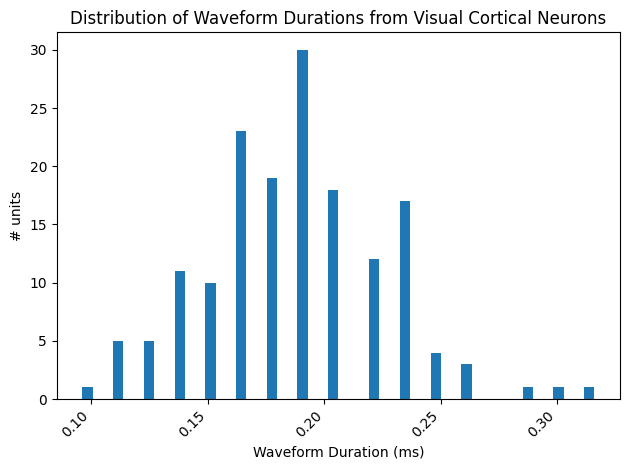

In [13]:
data = selected_waveform_duration

fig, ax = plt.subplots()
ax.hist(data, bins=50)

plt.xlabel(f"Waveform Duration ({waveform_duration_unit})")
plt.ylabel("# units")
plt.title("Distribution of Waveform Durations from Visual Cortical Neurons")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As you can see, there are two defined peaks in this bimodal distribution. We want to separate the FS neurons from the RS neurons, and to do so we must select a threshold point. This means that everything to the left of the point has shorter waveform durations and can be classified as FS neurons, and everything to the right of the point has longer waveform durations and can be classified as RS neurons. It is expected that this threshold is about 0.4 ms. The threshold point usually falls in the middle between the two peaks, and, for this plot, can be identified as the space between the 2 distributions that has the fewest number of units (0) for that time in the duration.

In [14]:
# define the threshold based on the plot above
threshold = 0.4

if waveform_duration_unit == "s":
	threshold /= 1000

## Plot The Waveform Profile of RS vs FS Neurons
Now that we have defined a threshold point that can classify FS neurons from RS neurons, we can plot the unit peak waveforms for each of these two categories and compare them. There are several steps that must be taken in order to do so. The waveform information in the units table is a 2D array that contains many waveforms for an individual unit. In order to select the peak waveform we want to plot from this 2D array, we need to index the array using the `local_index`. However, the local index data is stored in the electrodes table and not the units table. First, we need to create a dictionary that maps the `id` of each channel in the `electrodes` table to its associated `local_index`. This dictionary is necessary because by mapping the index to the channel ID, we can cross reference the data between the units table and the electodes table based on a specific identifier. Next, we use a for-loop to append the `selected_peak_waveform` to `selected_peak_waveform_rs` if the unit's duration is above the threshold value or `selected_peak_waveform_fs` if the unit's duration is less than the threshold value. We then plot the peak waveforms on top of each other for each type of neuron independently. 

In [15]:
selected_peak_waveform_rs = []
selected_peak_waveform_fs = []

for index, unit_row in units.loc[selected_unit_indices].iterrows():
    # column names can vary across nwbs:
    if 'waveform_duration' in units.columns:
        waveform_duration = unit_row['waveform_duration']
    else:
        waveform_duration = unit_row['half_width']
    unit_mean_waveform = unit_row['waveform_mean']
    peak_channel_idx = np.argmin(np.min(unit_mean_waveform, axis=0))
    peak_waveform = unit_mean_waveform[:, peak_channel_idx]

    if waveform_duration > threshold:
        selected_peak_waveform_rs.append(peak_waveform)
    else: 
        selected_peak_waveform_fs.append(peak_waveform)
        
print('number of RS waveforms to be plotted: ', len(selected_peak_waveform_rs))
print('number of FS waveforms to be plotted: ', len(selected_peak_waveform_fs))   

# convert lists into arrays and transpose for the plots
selected_peak_waveform_fs = np.array(selected_peak_waveform_fs).transpose()
selected_peak_waveform_rs = np.array(selected_peak_waveform_rs).transpose()

number of RS waveforms to be plotted:  134
number of FS waveforms to be plotted:  27


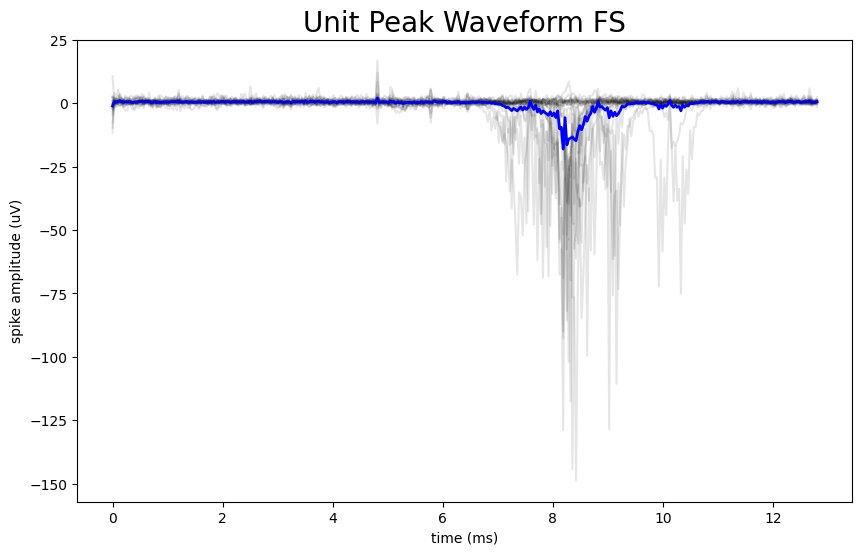

In [16]:
# these will be the same for each unit in this experiment, so we can index the first unit to define these values
one_device = list(nwb.devices.values())[0]
Hz = getattr(one_device, "sampling_rate", 30000) # default to 30000 if sampling_rate is not found
n_secs = peak_waveform.shape[0] / Hz

fig, ax = plt.subplots(figsize=(10,6))

n_secs = len(selected_peak_waveform_fs[:,0]) / Hz 
time_axis = np.linspace(0, n_secs * 1000, len(selected_peak_waveform_fs[:,0]))

ax.plot(time_axis, selected_peak_waveform_fs, color='k', alpha=0.1)
ax.plot(time_axis, np.mean(selected_peak_waveform_fs, axis=1), color='b', linewidth=2)

ax.set_xlabel("time (ms)")
ax.set_ylabel("spike amplitude (uV)")
ax.set_title("Unit Peak Waveform FS", fontsize=20)

plt.show()

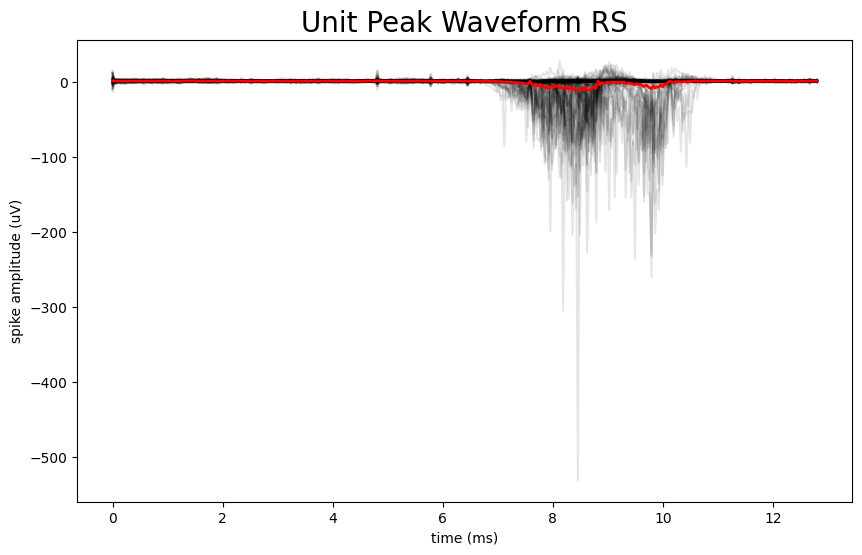

In [17]:
fig, ax = plt.subplots(figsize=(10,6))

# can do this because they are all the same length for this dataset 
n_secs = len(selected_peak_waveform_rs[:,0]) / Hz 
time_axis = np.linspace(0, n_secs * 1000, len(selected_peak_waveform_rs[:,0]))

ax.plot(time_axis, selected_peak_waveform_rs, color='k', alpha=0.1)
ax.plot(time_axis, np.mean(selected_peak_waveform_rs, axis=1), color='r', linewidth=2)

ax.set_xlabel("time (ms)")
ax.set_ylabel("spike amplitude (uV)")
ax.set_title("Unit Peak Waveform RS", fontsize=20)

plt.show()